Install the libFAUDES Python module from PyPI.org.

In [ ]:
!pip install faudes

Lets do a warmup. We have prompted Gemini 2.5 with

*I'ld like to compute the maximally permissive supervisor for two simple machines and a buffer of capacity 1.*

Gemini proposed a script with two or three minor syntactic flaws but otherwise just fine. The below code is Gemnini plus my minor fixes. Specifically the comments are all literatlly from Gemini and they make me feel confident.



Maximally Permissive Supervisor (S):
<Generator name="SupCon((M1||M2),(B))">

% 
%  Statistics for SupCon((M1||M2),(B))
% 
%  States:        6
%  Init/Marked:   1/1
%  Events:        4
%  Transitions:   8
%  StateSymbols:  6
%  Attrib. E/S/T: 0/0/0
% 

<Alphabet>
start1         finish1        start2         finish2       
</Alphabet>

<States>
I|I|E#1        B|I|E#2        I|I|F#3        I|B|E#5        B|B|E#6        I|B|F#7       
</States>

<TransRel>
I|I|E          start1         B|I|E         
B|I|E          finish1        I|I|F         
I|I|F          start2         I|B|E         
I|B|E          start1         B|B|E         
I|B|E          finish2        I|I|E         
B|B|E          finish1        I|B|F         
B|B|E          finish2        B|I|E         
I|B|F          finish2        I|I|F         
</TransRel>

<InitStates>
I|I|E         
</InitStates>

<MarkedStates>
I|I|E         
</MarkedStates>


</Generator>


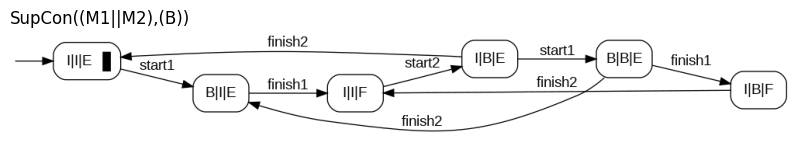

In [ ]:
# Get the libFAUDES module
from faudes import *

# Define Machine 1 (M1)
# M1 can start (start1) and then finish (finish1) a task.
gM1 = Generator.NewFromLists(
    delta=[
        ['I', 'start1', 'B'],
        ['B', 'finish1', 'I']
    ],
    Q0=['I'],
    Qm=['I']
)
gM1.Name("M1")

# Define Machine 2 (M2)
# M2 can start (start2) and then finish (finish2) a task.
gM2 = Generator.NewFromLists(
    delta=[
        ['I', 'start2', 'B'],
        ['B', 'finish2', 'I']
    ],
    Q0=['I'],
    Qm=['I']
)
gM2.Name("M2")


# Define Buffer (capacity 1)
# The buffer receives an item when M1 finishes (finish1) and provides an item
# when M2 starts (start2). It has states 'E(empty)' and 'F(ull)'.
gB = Generator.NewFromLists(
    delta=[
        ['E', 'finish1', 'F'],
        ['F', 'start2', 'E']
    ],
    Q0=['E'],
    Qm=['E'],
    Sigma=['finish1', 'start2']
)
gB.Name("B")


# Compose the plant
gM12 = Parallel(gM1, gM2)

# Lift the specs to the overall alphabet
InvProject(gB,gM12.Alphabet())

# Define controllable events
# Assume 'start' events are controllable (we can decide when to start a machine).
# Assume 'finish' events are uncontrollable (machines finish tasks on their own).
Sig_c = EventSet.NewFromList(['start1', 'start2'])

# Synthesize the maximally permissive supervisor
# The goal is to supervise G, ensuring the buffer capacity constraint.
S = SupCon(gM12, Sig_c, gB)

# Display information about the synthesized supervisor
print("\nMaximally Permissive Supervisor (S):")
S.Write()

# We visualize the supervisor (without symbolic state names)
S.GraphShow()


My next prompt was "Can we increase the buffer capacity to 2?". Gemini maintained my minor fixes from the first round (nice) and seamlessly increased the buffer capacity as requested (wow). The below script is the original answer --- no edits.


Maximally Permissive Supervisor (S) with buffer capacity 2:
<Generator name="SupCon((M1||M2),(B_Capacity2))">

% 
%  Statistics for SupCon((M1||M2),(B_Capacity2))
% 
%  States:        10
%  Init/Marked:   1/1
%  Events:        4
%  Transitions:   16
%  StateSymbols:  10
%  Attrib. E/S/T: 0/0/0
% 

<Alphabet>
start1         finish1        start2         finish2       
</Alphabet>

<States>
I|I|B0#1       B|I|B0#2       I|I|B1#3       B|I|B1#4       I|B|B0#5       B|B|B0#6      
I|B|B1#7       B|B|B1#8       I|B|B2#9       I|I|B2#11     
</States>

<TransRel>
I|I|B0         start1         B|I|B0        
B|I|B0         finish1        I|I|B1        
I|I|B1         start1         B|I|B1        
I|I|B1         start2         I|B|B0        
B|I|B1         finish1        I|I|B2        
B|I|B1         start2         B|B|B0        
I|B|B0         start1         B|B|B0        
I|B|B0         finish2        I|I|B0        
B|B|B0         finish1        I|B|B1        
B|B|B0         finish2        

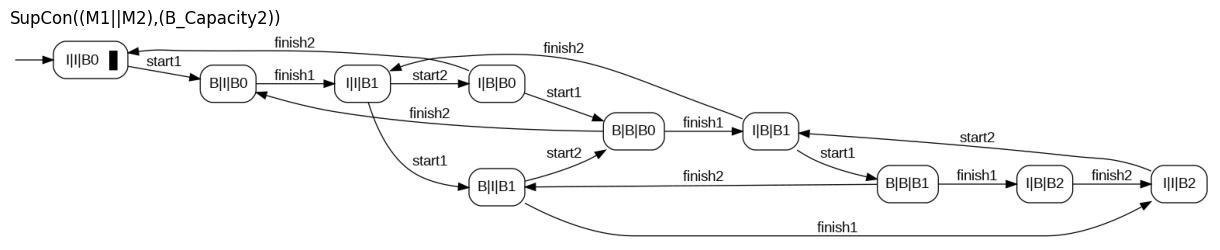

In [ ]:
# Redefine Buffer (capacity 2)
# The buffer receives an item when M1 finishes (finish1) and provides an item
# when M2 starts (start2). It has states 'B0' (empty), 'B1' (one item), 'B2' (two items).
gB = Generator.NewFromLists(
    delta=[
        ['B0', 'finish1', 'B1'], # Empty to one item
        ['B1', 'finish1', 'B2'], # One item to two items (full)
        ['B1', 'start2', 'B0'],  # One item to empty
        ['B2', 'start2', 'B1']   # Two items to one item
    ],
    Q0=['B0'],
    Qm=['B0'],
    Sigma=['finish1', 'start2']
)
gB.Name("B_Capacity2")

# Compose the plant (re-using gM1 and gM2 from previous cell)
gM12 = Parallel(gM1, gM2)

# Lift the specs to the overall alphabet
InvProject(gB,gM12.Alphabet())

# Synthesize the maximally permissive supervisor with the new buffer capacity
# Sig_c is already defined from the previous cell.
S = SupCon(gM12, Sig_c, gB)

# Display information about the synthesized supervisor
print("\nMaximally Permissive Supervisor (S) with buffer capacity 2:")
S.Write()

# We visualize the supervisor (without symbolic state names)
S.GraphShow()

Hmmm... wonder this:

*I will not overstress it but in my mind I have even larger buffers. Can we parameterise this?*

The answer was:

*That's a great idea! Parameterizing the buffer capacity will make it much easier to experiment with different buffer sizes. I've created a Python function create_buffer_generator that takes the
capacity as an argument and returns the corresponding buffer generator.*


Then there come some instructions on how to use that function. I did absolutely no edits, from this line on its 100% Gemini 2.5 incl. the comments. Apparantly Gemini was uncertain which states I wanted to have marked. In its initial proposal for capacity one, Gemini marked all states but in my edits I changed this to only the initial state being marked.

In [ ]:
def create_buffer_generator(capacity):
    """
    Creates a buffer Generator for a given capacity.

    Args:
        capacity (int): The maximum number of items the buffer can hold.

    Returns:
        Generator: The faudes Generator object representing the buffer.
    """
    if capacity < 0:
        raise ValueError("Buffer capacity cannot be negative.")

    delta = []
    Q0 = ['B0'] # Initial state is always empty
    Qm = ['B0'] # Marked states are usually where the buffer is empty or has items (depending on interpretation)

    # Generate states for the buffer: B0, B1, ..., B_capacity
    states = [f'B{i}' for i in range(capacity + 1)]

    for i in range(capacity + 1):
        current_state = states[i]

        # finish1 adds an item to the buffer
        if i < capacity:
            next_state_finish1 = states[i + 1]
            delta.append([current_state, 'finish1', next_state_finish1])

        # start2 removes an item from the buffer
        if i > 0:
            next_state_start2 = states[i - 1]
            delta.append([current_state, 'start2', next_state_start2])

    # For this problem, we want all states where the buffer is not overflowing to be marked.
    # However, for supervisor synthesis with an invariant, the marked states of the invariant
    # typically represent the 'good' states. Here, we'll mark all states up to capacity.
    # In the original problem, Qm was just ['E'] or ['B0'] for a capacity of 1 and 2 respectively,
    # implying that the supervisor should ensure the buffer eventually returns to empty.
    # Let's keep Qm as just the initial empty state to match previous behavior.
    # If the intent is to allow the system to stay in any non-full state, Qm would be states up to capacity.
    gB = Generator.NewFromLists(
        delta=delta,
        Q0=['B0'],
        Qm=['B0'], # Keeping Qm as ['B0'] to match previous examples' implicit goal of returning to empty
        Sigma=['finish1', 'start2']
    )
    gB.Name(f"B_Capacity{capacity}")
    return gB

[Gemini:] *Now, let's use this function to reproduce the supervisor for a buffer capacity of 1:*


Maximally Permissive Supervisor (S) with buffer capacity 1:
<Generator name="SupCon((M1||M2),(B_Capacity1))">

% 
%  Statistics for SupCon((M1||M2),(B_Capacity1))
% 
%  States:        6
%  Init/Marked:   1/1
%  Events:        4
%  Transitions:   8
%  StateSymbols:  6
%  Attrib. E/S/T: 0/0/0
% 

<Alphabet>
start1         finish1        start2         finish2       
</Alphabet>

<States>
I|I|B0#1       B|I|B0#2       I|I|B1#3       I|B|B0#5       B|B|B0#6       I|B|B1#7      
</States>

<TransRel>
I|I|B0         start1         B|I|B0        
B|I|B0         finish1        I|I|B1        
I|I|B1         start2         I|B|B0        
I|B|B0         start1         B|B|B0        
I|B|B0         finish2        I|I|B0        
B|B|B0         finish1        I|B|B1        
B|B|B0         finish2        B|I|B0        
I|B|B1         finish2        I|I|B1        
</TransRel>

<InitStates>
I|I|B0        
</InitStates>

<MarkedStates>
I|I|B0        
</MarkedStates>


</Generator>


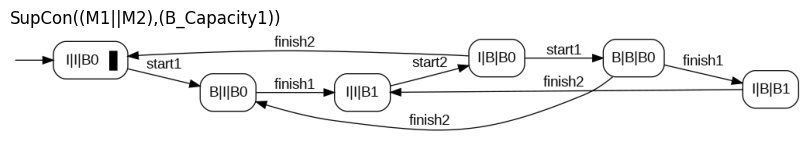

In [ ]:
# --- Buffer Capacity 1 ---

# Create buffer for capacity 1
gB_cap1 = create_buffer_generator(1)

# Compose the plant (re-using gM1 and gM2 from previous cell)
gM12 = Parallel(gM1, gM2)

# Lift the specs to the overall alphabet
InvProject(gB_cap1, gM12.Alphabet())

# Synthesize the maximally permissive supervisor
S_cap1 = SupCon(gM12, Sig_c, gB_cap1)

print("\nMaximally Permissive Supervisor (S) with buffer capacity 1:")
S_cap1.Write()
S_cap1.GraphShow()

[Gemini:] *And now for a buffer capacity of 2:*


Maximally Permissive Supervisor (S) with buffer capacity 2:
<Generator name="SupCon((M1||M2),(B_Capacity2))">

% 
%  Statistics for SupCon((M1||M2),(B_Capacity2))
% 
%  States:        10
%  Init/Marked:   1/1
%  Events:        4
%  Transitions:   16
%  StateSymbols:  10
%  Attrib. E/S/T: 0/0/0
% 

<Alphabet>
start1         finish1        start2         finish2       
</Alphabet>

<States>
I|I|B0#1       B|I|B0#2       I|I|B1#3       B|I|B1#4       I|B|B0#5       B|B|B0#6      
I|B|B1#7       B|B|B1#8       I|B|B2#9       I|I|B2#11     
</States>

<TransRel>
I|I|B0         start1         B|I|B0        
B|I|B0         finish1        I|I|B1        
I|I|B1         start1         B|I|B1        
I|I|B1         start2         I|B|B0        
B|I|B1         finish1        I|I|B2        
B|I|B1         start2         B|B|B0        
I|B|B0         start1         B|B|B0        
I|B|B0         finish2        I|I|B0        
B|B|B0         finish1        I|B|B1        
B|B|B0         finish2        

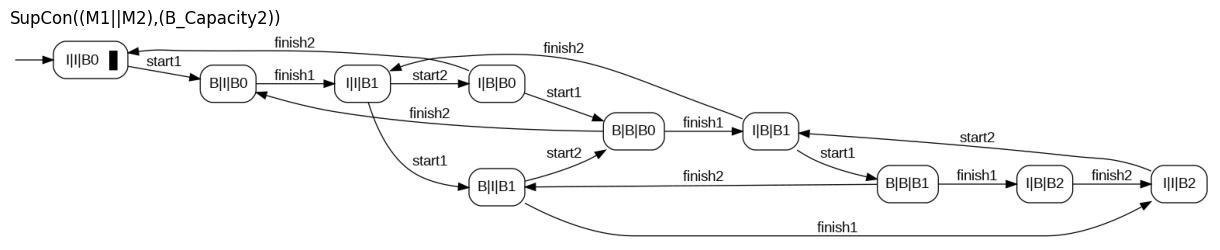

In [ ]:
# --- Buffer Capacity 2 ---

# Create buffer for capacity 2
gB_cap2 = create_buffer_generator(2)

# Compose the plant (re-using gM1 and gM2)
gM12 = Parallel(gM1, gM2)

# Lift the specs to the overall alphabet
InvProject(gB_cap2, gM12.Alphabet())

# Synthesize the maximally permissive supervisor
S_cap2 = SupCon(gM12, Sig_c, gB_cap2)

print("\nMaximally Permissive Supervisor (S) with buffer capacity 2:")
S_cap2.Write()
S_cap2.GraphShow()

Human back in the loop. We want to do some validation.
Our Prompt:

*I would now like to verify that the result from the parametrised buffer with capacity 2 is identical to the "hand coded" version. Can you provide code that tests language equality for the respective supervisors?*

Gemini got is almost correct, except that it had no chance to know how the respective faudes function is named. Replacing the proposed "IsEqual" with "LanguageEquality" we are fine.



In [ ]:
# Compare the supervisor from the parameterized function (S_cap2) with the hand-coded version (S)
# Both are for buffer capacity 2.

is_equal = LanguageEquality(S_cap2, S)

print(f"\nAre the supervisors for capacity 2 (parameterized vs. hand-coded) language-equal?\n{is_equal}")


Are the supervisors for capacity 2 (parameterized vs. hand-coded) language-equal?
True
